# Supervised ResNet18 baseline (log-STFT)

Усиленный supervised-бейзлайн (B1) для **классификации видов летучих мышей** по аудиозаписям.

**Пайплайн:** WAV → resample → crop 2 с → log-STFT (5–96 kHz) → ResNet18 → класс вида.

По сравнению с минимальным CNN-бейзлайном здесь более глубокий backbone, energy-biased crop, SpecAugment, балансировка редких классов и label smoothing. Основные метрики — macro/weighted F1 (ориентир NABat).

**Данные:** `cleaned_subset_200/`, `audio_metadata_cleaned.csv`  
**Чекпоинт:** `checkpoints/resnet18_bat_best.pt`


In [1]:

from pathlib import Path
import os

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from scipy import signal
import soundfile as sf
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
)
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet18
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
from tqdm.auto import tqdm

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ClearML и пути

Задаются пути к данным и чекпоинтам, подгружается `.env`, выбирается device и инициализируется **ClearML Task**.

В эксперимент пишутся гиперпараметры, scalar-метрики по эпохам и веса лучшей модели (критерий отбора — macro-F1 на validation).


In [2]:

PROJECT_DIR = Path("/Users/katterns/ITMO/Practice")
DATA_DIR = PROJECT_DIR / "cleaned_subset_200"
METADATA_PATH = DATA_DIR / "audio_metadata_cleaned.csv"
CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
BEST_CKPT = CHECKPOINT_DIR / "resnet18_bat_best.pt"
TRAIN_LOG_TXT = CHECKPOINT_DIR / "resnet18_bat_train_log.txt"

import logging
from dotenv import load_dotenv

load_dotenv(PROJECT_DIR / ".env", override=False)

CLEARML_QUIET = os.environ.get("CLEARML_QUIET", "1").strip().lower() in ("1", "true", "yes")
# False = upload только финальный best (без progress bar на каждую эпоху)
CLEARML_UPLOAD_EACH_BEST = os.environ.get("CLEARML_UPLOAD_EACH_BEST", "0").strip().lower() in (
    "1", "true", "yes",
)


def setup_clearml_console(quiet: bool = True) -> None:
    if not quiet:
        return
    for name in ("clearml", "clearml.storage", "clearml.model", "clearml.Task"):
        logging.getLogger(name).setLevel(logging.WARNING)
    try:
        from clearml.storage.callbacks import ProgressReport

        def _no_tqdm(self):
            self._tqdm_init = True
            return None

        ProgressReport._get_tqdm = _no_tqdm
    except Exception:
        pass


setup_clearml_console(CLEARML_QUIET)

from clearml import OutputModel, Task

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

clearml_output_uri = os.environ.get("CLEARML_OUTPUT_URI", True)
if isinstance(clearml_output_uri, str) and clearml_output_uri.lower() in ("false", "0", "no", "none"):
    clearml_output_uri = False

clearml_task = Task.init(
    project_name=os.environ.get("CLEARML_PROJECT", "my project"),
    task_name=os.environ.get("CLEARML_TASK_NAME", "resnet18_bat_b1_2sec"),
    output_uri=clearml_output_uri,
    reuse_last_task_id=False,
    auto_resource_monitoring=False,
)
output_dest = clearml_task.get_output_destination() or ""
output_model = OutputModel(
    task=clearml_task,
    name="resnet18_bat_b1",
    framework="pytorch",
)
if output_dest:
    output_model.set_upload_destination(output_dest)

if not CLEARML_QUIET:
    print("ClearML:", clearml_task.get_output_log_web_page())
print("device:", device, "| quiet:", CLEARML_QUIET, "| upload each best:", CLEARML_UPLOAD_EACH_BEST)


ClearML Task: created new task id=7fe8a25fa9d84f88830b3d435ee40286
ClearML results page: https://app.clear.ml/projects/6c3eac4aaa974ff39b83424d3f26990c/experiments/7fe8a25fa9d84f88830b3d435ee40286/output/log
device: mps | quiet: True | upload each best: False


# Аудио и log-STFT

Функции предобработки сигнала до подачи в сеть:

- **Resample** до 192 kHz — единая частота дискретизации для всех записей.
- **Crop 2 с:** на train — случайный или *energy-biased* crop (выбирается окно с большей энергией); на val — центральный crop или padding.
- **STFT → log(1+|·|):** оставляются частоты **5–96 kHz** (band-pass), спектр приводится к размеру **128×256** и нормализуется по mean/std внутри сэмпла.
- **Augment (только train):** маски по времени и частоте (SpecAugment) + случайный jitter громкости.


In [3]:

TARGET_SR = 192_000
CLIP_SEC = 2.0
MIN_FREQ = 5_000
MAX_FREQ = 96_000
SPEC_H, SPEC_W = 128, 256
N_FFT = 2048
HOP_LENGTH = 512

SPEC_TIME_MASK_MAX = 24
SPEC_FREQ_MASK_MAX = 16
GAIN_JITTER_DB = 6.0
ENERGY_CROP_PROB = 0.7
ENERGY_CROP_CANDIDATES = 8


def resample_audio(y: np.ndarray, orig_sr: float, target_sr: float) -> np.ndarray:
    if int(orig_sr) == int(target_sr):
        return y.astype(np.float32)
    t_old = np.linspace(0.0, len(y) / orig_sr, num=len(y), endpoint=False)
    t_new = np.linspace(
        0.0,
        len(y) / orig_sr,
        num=int(len(y) * target_sr / orig_sr),
        endpoint=False,
    )
    return np.interp(t_new, t_old, y).astype(np.float32)


def center_crop_or_pad(y: np.ndarray, target_len: int) -> np.ndarray:
    if len(y) >= target_len:
        i0 = (len(y) - target_len) // 2
        return y[i0 : i0 + target_len]
    out = np.zeros(target_len, dtype=np.float32)
    i0 = (target_len - len(y)) // 2
    out[i0 : i0 + len(y)] = y
    return out


def random_crop_or_pad(y: np.ndarray, target_len: int, rng: np.random.Generator) -> np.ndarray:
    if len(y) >= target_len:
        i0 = int(rng.integers(0, len(y) - target_len + 1))
        return y[i0 : i0 + target_len]
    out = np.zeros(target_len, dtype=np.float32)
    i0 = (target_len - len(y)) // 2
    out[i0 : i0 + len(y)] = y
    return out


def energy_biased_crop(
    y: np.ndarray, target_len: int, rng: np.random.Generator, n_candidates: int
) -> np.ndarray:
    if len(y) < target_len:
        return center_crop_or_pad(y, target_len)
    best_i0, best_e = 0, -1.0
    for _ in range(n_candidates):
        i0 = int(rng.integers(0, len(y) - target_len + 1))
        seg = y[i0 : i0 + target_len]
        e = float(np.mean(seg * seg))
        if e > best_e:
            best_e, best_i0 = e, i0
    return y[best_i0 : best_i0 + target_len]


def pick_train_crop(y: np.ndarray, target_len: int, rng: np.random.Generator) -> np.ndarray:
    if rng.random() < ENERGY_CROP_PROB:
        return energy_biased_crop(y, target_len, rng, ENERGY_CROP_CANDIDATES)
    return random_crop_or_pad(y, target_len, rng)


def make_log_stft(audio: np.ndarray, sr: float) -> np.ndarray:
    audio = np.asarray(audio, dtype=np.float32)
    audio = audio[np.isfinite(audio)]
    if len(audio) < 8:
        raise ValueError("Audio too short")
    nperseg = int(min(N_FFT, len(audio)))
    hop = int(min(HOP_LENGTH, max(1, nperseg // 2)))
    noverlap = max(0, nperseg - hop)
    if noverlap >= nperseg:
        noverlap = nperseg - 1
    freqs, _, zxx = signal.stft(
        audio,
        fs=sr,
        nperseg=nperseg,
        noverlap=noverlap,
        boundary="zeros",
        padded=True,
    )
    spec = np.log1p(np.abs(zxx))
    keep = (freqs >= MIN_FREQ) & (freqs <= min(MAX_FREQ, sr / 2))
    return spec[keep]


def spec_to_tensor(spec: np.ndarray) -> torch.Tensor:
    spec = np.ascontiguousarray(spec, dtype=np.float32)
    x = torch.from_numpy(spec)[None, None]
    x = F.interpolate(x, size=(SPEC_H, SPEC_W), mode="bilinear", align_corners=False)
    x = x[0]
    x = (x - x.mean()) / (x.std().clamp_min(1e-6))
    return x


def augment_spec(x: torch.Tensor, rng: np.random.Generator) -> torch.Tensor:
    _, h, w = x.shape
    if SPEC_FREQ_MASK_MAX > 0:
        fh = int(rng.integers(0, SPEC_FREQ_MASK_MAX + 1))
        if fh > 0:
            f0 = int(rng.integers(0, max(1, h - fh)))
            x = x.clone()
            x[:, f0 : f0 + fh, :] = 0.0
    if SPEC_TIME_MASK_MAX > 0:
        tw = int(rng.integers(0, SPEC_TIME_MASK_MAX + 1))
        if tw > 0:
            t0 = int(rng.integers(0, max(1, w - tw)))
            x = x.clone()
            x[:, :, t0 : t0 + tw] = 0.0
    if GAIN_JITTER_DB > 0:
        gain = 10.0 ** (float(rng.uniform(-GAIN_JITTER_DB, GAIN_JITTER_DB)) / 20.0)
        x = x * gain
    return x


# Датасет

Из CSV читаются метаданные: для каждой строки строится путь к WAV-файлу и числовая метка вида.

Виды кодируются в `label` через словарь `species → id`. Записи без файла на диске отбрасываются. Далее — **stratified split** 85% train / 15% val с сохранением долей классов.


In [4]:

df = pd.read_csv(METADATA_PATH)

species_sorted = sorted(df["species"].unique())
label2id = {s: i for i, s in enumerate(species_sorted)}
id2label = {i: s for s, i in label2id.items()}
n_classes = len(species_sorted)

df["label"] = df["species"].map(label2id)
df["path"] = df.apply(
    lambda r: DATA_DIR / str(r["species"]) / str(r["filename"]), axis=1
)
df = df[df["path"].apply(lambda p: p.is_file())].reset_index(drop=True)

train_df, val_df = train_test_split(
    df,
    test_size=0.15,
    random_state=RANDOM_SEED,
    stratify=df["label"],
)
print(f"Train: {len(train_df)}  Val: {len(val_df)}  Классов: {n_classes}")

vc_train = train_df["species"].value_counts().sort_values()
print(
    f"Классы train: min={vc_train.min()} max={vc_train.max()} "
    f"ratio={vc_train.max() / max(vc_train.min(), 1):.2f}"
)
display(vc_train.head(8))


Train: 4348  Val: 768  Классов: 26
Классы train: min=133 max=170 ratio=1.28


species
LABL    133
COTO    142
NYMA    163
LASE    170
MYYU    170
MYSO    170
MYVO    170
PAHE    170
Name: count, dtype: int64

# Dataset

`BatWavSpectrogramDataset` в `__getitem__` читает WAV, прогоняет его через препроцессинг и возвращает `(спектрограмма 1×128×256, label)`.

На **train** включены аугментации; на **val** — центральный crop/pad без аугментаций.


In [5]:

class BatWavSpectrogramDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, training: bool = False):
        self.frame = frame.reset_index(drop=True)
        self.training = training
        self.rng = np.random.default_rng(RANDOM_SEED)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        y, sr = sf.read(str(row["path"]), always_2d=False)
        if y.ndim > 1:
            y = y.mean(axis=-1)
        y = resample_audio(y, float(sr), float(TARGET_SR))
        tgt = int(CLIP_SEC * TARGET_SR)
        if self.training:
            y = pick_train_crop(y, tgt, self.rng)
        else:
            y = center_crop_or_pad(y, tgt)
        spec = make_log_stft(y, float(TARGET_SR))
        x = spec_to_tensor(spec)
        if self.training:
            x = augment_spec(x, self.rng)
        return x, int(row["label"])


# DataLoader

Сборка train/val loaders. Для train — `WeightedRandomSampler` (вес ∝ 1 / число примеров класса), чтобы редкие виды чаще попадали в батч. `batch_size=64`.


In [6]:

train_ds = BatWavSpectrogramDataset(train_df, training=True)
val_ds = BatWavSpectrogramDataset(val_df, training=False)

label_counts = train_df["label"].value_counts().sort_index()
inv_count = {lbl: 1.0 / cnt for lbl, cnt in label_counts.items()}
sample_weights = train_df["label"].map(inv_count).values
train_sampler = torch.utils.data.WeightedRandomSampler(
    weights=torch.as_tensor(
        np.asarray(sample_weights, dtype=np.float64).copy(), dtype=torch.double
    ),
    num_samples=len(train_df),
    replacement=True,
)

BATCH_SIZE = 64
NUM_WORKERS = 0

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=False,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False,
)

xb, yb = next(iter(train_loader))
print("batch:", xb.shape, yb.shape)


batch: torch.Size([64, 1, 128, 256]) torch.Size([64])


# ResNet18

Класс `ResNet18Bat` — ResNet18 **без ImageNet-претрейна**: первый свёрточный слой принимает **1 канал** (log-STFT), голова — Dropout (0.3) + Linear на число классов. Архитектура следует практике ANIMAL-SPOT / BatSpot для bioacoustics.


In [7]:

class ResNet18Bat(nn.Module):
    def __init__(self, n_classes: int, dropout: float = 0.3):
        super().__init__()
        backbone = resnet18(weights=None)
        backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        in_features = backbone.fc.in_features
        backbone.fc = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, n_classes),
        )
        self.backbone = backbone

    def forward(self, x):
        return self.backbone(x)


In [8]:

model = ResNet18Bat(n_classes).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"ResNet18 params: {n_params:,}")
with torch.no_grad():
    print("logits:", model(xb.to(device)).shape)


ResNet18 params: 11,183,578
logits: torch.Size([64, 26])


# Гиперпараметры и оптимизация

`CrossEntropyLoss` с label smoothing, AdamW, ReduceLROnPlateau по macro-F1 на val. Гиперпараметры также уходят в ClearML через `task.connect()`.


In [9]:

LR = 1e-3
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.1
MAX_EPOCHS = 40
PATIENCE = 10
LR_PLATEAU_PATIENCE = 5
LR_FACTOR = 0.5
LR_MIN = 1e-7
MAX_GRAD_NORM = 1.0

clearml_task.connect({
    "model": "resnet18",
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
    "label_smoothing": LABEL_SMOOTHING,
    "max_epochs": MAX_EPOCHS,
    "patience": PATIENCE,
    "batch_size": BATCH_SIZE,
    "clip_sec": CLIP_SEC,
    "min_freq": MIN_FREQ,
    "max_freq": MAX_FREQ,
    "energy_crop_prob": ENERGY_CROP_PROB,
    "device": str(device),
})

loss_function = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=LR_FACTOR,
    patience=LR_PLATEAU_PATIENCE,
    min_lr=LR_MIN,
)


# Функции обучения

- `evaluate(model)` — loss и метрики на validation без градиентов.
- `train_model(...)` — прогресс по эпохам и батчам; метрики по эпохам уходят в ClearML.
- Лучший чекпоинт сохраняется локально и загружается в ClearML.


In [10]:

@torch.no_grad()
def evaluate(model):
    model.eval()

    loss_epoch = 0.0
    num_samples = 0
    preds_list = []
    targets_list = []

    for batch_x, target in val_loader:
        batch_x = batch_x.to(device)
        target = target.to(device)
        logits = model(batch_x)
        loss = loss_function(logits, target)
        num = logits.shape[0]
        loss_epoch += loss.item() * num
        num_samples += num

        preds_list.extend(logits.argmax(dim=-1).cpu().tolist())
        targets_list.extend(target.cpu().tolist())

    y_true = np.array(targets_list)
    y_pred = np.array(preds_list)
    metrics = {
        "acc": accuracy_score(y_true, y_pred),
        "bal_acc": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "weighted_prec": precision_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
    }
    return loss_epoch / max(num_samples, 1), metrics, y_true, y_pred


In [11]:


def _upload_checkpoint_to_clearml(epoch: int) -> str | None:
    if not output_dest:
        return None
    return output_model.update_weights(
        weights_filename=str(BEST_CKPT),
        upload_uri=output_dest or None,
        auto_delete_file=False,
        iteration=epoch,
    )


def _save_best_checkpoint(epoch, macro_f1, metrics):
    torch.save(
        {
            "model_state": model.state_dict(),
            "model_name": "resnet18_bat",
            "label2id": label2id,
            "id2label": id2label,
            "config": {
                "target_sr": TARGET_SR,
                "clip_sec": CLIP_SEC,
                "min_freq": MIN_FREQ,
                "max_freq": MAX_FREQ,
                "spec_hw": (SPEC_H, SPEC_W),
                "n_fft": N_FFT,
                "hop_length": HOP_LENGTH,
                "label_smoothing": LABEL_SMOOTHING,
            },
            "val_macro_f1": macro_f1,
            "val_weighted_f1": metrics["weighted_f1"],
            "val_balanced_acc": metrics["bal_acc"],
            "epoch": epoch,
        },
        BEST_CKPT,
    )
    model_uri = None
    if CLEARML_UPLOAD_EACH_BEST:
        model_uri = _upload_checkpoint_to_clearml(epoch)
    line = f"epoch={epoch} macro_f1={macro_f1:.4f} w_f1={metrics['weighted_f1']:.4f}\n"
    TRAIN_LOG_TXT.write_text(
        (TRAIN_LOG_TXT.read_text(encoding="utf-8") if TRAIN_LOG_TXT.exists() else "")
        + line,
        encoding="utf-8",
    )
    if CLEARML_QUIET:
        tqdm.write(f"saved {BEST_CKPT.name}  macro_f1={macro_f1:.4f}")
    else:
        msg = f"saved {BEST_CKPT}"
        if model_uri:
            msg += f"  ClearML: {model_uri}"
        tqdm.write(msg)


def train_model(model, num_epochs=40, max_grad_norm=1.0):
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_macro_f1": [],
        "val_weighted_f1": [],
        "val_acc": [],
    }

    best_macro_f1 = -1.0
    best_epoch = 0
    epochs_no_improve = 0
    logger = clearml_task.get_logger()

    epoch_bar = tqdm(
        range(1, num_epochs + 1),
        desc="epochs",
        unit="epoch",
        position=0,
        leave=True,
    )
    for epoch in epoch_bar:
        model.train()
        epoch_train_loss = 0.0
        epoch_train_n = 0

        batch_bar = tqdm(
            train_loader,
            desc=f"train e{epoch}",
            leave=False,
            unit="batch",
            position=1,
        )
        for batch_x, target in batch_bar:
            batch_x = batch_x.to(device)
            target = target.to(device)

            optimizer.zero_grad(set_to_none=True)
            logits = model(batch_x)
            loss = loss_function(logits, target)
            loss.backward()
            if max_grad_norm is not None:
                nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()

            batch_n = batch_x.size(0)
            epoch_train_loss += loss.item() * batch_n
            epoch_train_n += batch_n

            batch_preds = logits.argmax(dim=-1).cpu().tolist()
            batch_f1 = f1_score(
                target.cpu().tolist(),
                batch_preds,
                average="macro",
                zero_division=0,
            )
            batch_bar.set_postfix(loss=f"{loss.item():.4f}", f1=f"{batch_f1:.3f}")

        tr_loss = epoch_train_loss / max(epoch_train_n, 1)
        val_loss, metrics, y_true, y_pred = evaluate(model)
        lr_now = optimizer.param_groups[0]["lr"]
        macro_f1 = metrics["macro_f1"]

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_loss)
        history["val_macro_f1"].append(macro_f1)
        history["val_weighted_f1"].append(metrics["weighted_f1"])
        history["val_acc"].append(metrics["acc"])

        for name, val in metrics.items():
            logger.report_scalar("metrics", name, val, iteration=epoch)
        logger.report_scalar("loss", "train", tr_loss, iteration=epoch)
        logger.report_scalar("loss", "val", val_loss, iteration=epoch)
        logger.report_scalar("lr", "lr", lr_now, iteration=epoch)

        pred_top3 = pd.Series(y_pred).map(id2label).value_counts().head(3).to_dict()
        epoch_bar.set_postfix(macro_f1=f"{macro_f1:.4f}", val_loss=f"{val_loss:.4f}")
        tqdm.write(
            f"Epoch {epoch:02d}  lr={lr_now:.2e}  train={tr_loss:.4f}  val={val_loss:.4f}  "
            f"acc={metrics['acc']:.4f}  macro_f1={macro_f1:.4f}  "
            f"w_f1={metrics['weighted_f1']:.4f}  w_prec={metrics['weighted_prec']:.4f}  "
            f"top3={pred_top3}"
        )

        if macro_f1 > best_macro_f1:
            best_macro_f1 = macro_f1
            best_epoch = epoch
            epochs_no_improve = 0
            _save_best_checkpoint(epoch, macro_f1, metrics)
        else:
            epochs_no_improve += 1

        scheduler.step(macro_f1)

        if epochs_no_improve >= PATIENCE:
            tqdm.write("Early stopping.")
            break

    epoch_bar.close()
    if best_macro_f1 > 0 and output_dest and not CLEARML_UPLOAD_EACH_BEST:
        uri = _upload_checkpoint_to_clearml(best_epoch)
        if not CLEARML_QUIET and uri:
            tqdm.write(f"ClearML upload (final best, ep {best_epoch}): {uri}")
    tqdm.write(f"best macro_f1 (val): {best_macro_f1:.4f}")
    return model, history


# Запуск обучения


In [12]:

model, history = train_model(
    model,
    num_epochs=MAX_EPOCHS,
    max_grad_norm=MAX_GRAD_NORM,
)


epochs:   0%|          | 0/40 [00:00<?, ?epoch/s]

train e1:   0%|          | 0/68 [00:00<?, ?batch/s]

Epoch 01  lr=1.00e-03  train=2.3197  val=1.8875  acc=0.4935  macro_f1=0.4635  w_f1=0.4663  w_prec=0.5366  top3={'MYCI': 81, 'MYSO': 76, 'MYTH': 62}
saved resnet18_bat_best.pt  macro_f1=0.4635


train e2:   0%|          | 0/68 [00:00<?, ?batch/s]

Epoch 02  lr=1.00e-03  train=1.7993  val=1.8257  acc=0.5378  macro_f1=0.5151  w_f1=0.5141  w_prec=0.5792  top3={'MYSE': 99, 'COTO': 61, 'MYVO': 53}
saved resnet18_bat_best.pt  macro_f1=0.5151


...

Epoch 38  lr=1.00e-03  train=0.9635  val=1.2310  acc=0.7878  macro_f1=0.7845  w_f1=0.7836  w_prec=0.7982  top3={'MYCI': 46, 'MYLE': 44, 'LANO': 40}


train e39:   0%|          | 0/68 [00:00<?, ?batch/s]

Epoch 39  lr=1.00e-03  train=0.9334  val=1.2170  acc=0.7839  macro_f1=0.7840  w_f1=0.7823  w_prec=0.7889  top3={'LANO': 40, 'MYTH': 39, 'LABO': 35}


train e40:   0%|          | 0/68 [00:00<?, ?batch/s]

Epoch 40  lr=5.00e-04  train=0.8815  val=1.1685  acc=0.8177  macro_f1=0.8182  w_f1=0.8175  w_prec=0.8247  top3={'MYSE': 44, 'LANO': 41, 'MYTH': 34}
saved resnet18_bat_best.pt  macro_f1=0.8182
best macro_f1 (val): 0.8182


# История обучения

Локальные графики loss и F1 по эпохам

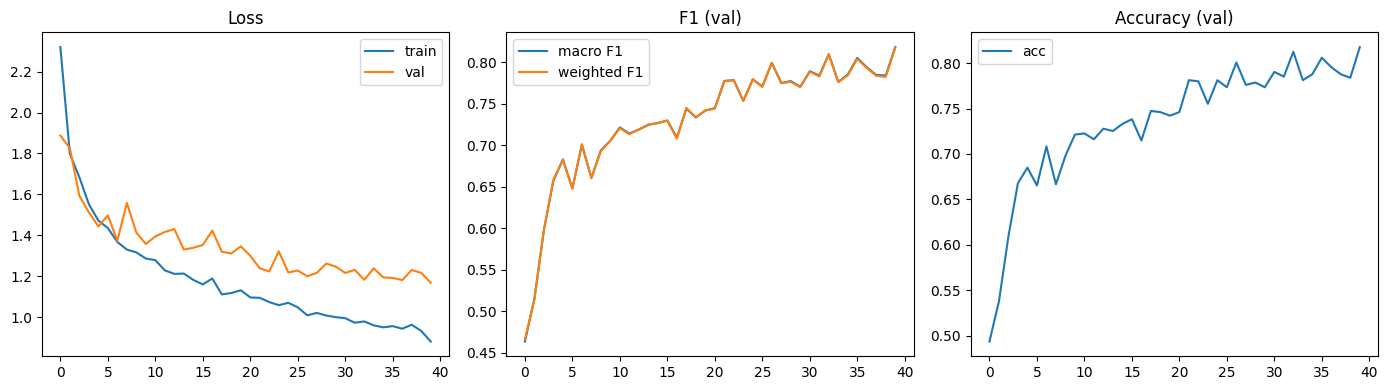

In [13]:

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()
axes[1].plot(history["val_macro_f1"], label="macro F1")
axes[1].plot(history["val_weighted_f1"], label="weighted F1")
axes[1].set_title("F1 (val)")
axes[1].legend()
axes[2].plot(history["val_acc"], label="acc")
axes[2].set_title("Accuracy (val)")
axes[2].legend()
plt.tight_layout()
plt.show()


# Оценка на validation

Загружается лучший чекпоинт (по macro-F1 за обучение). Считаются accuracy, balanced accuracy, macro/weighted F1 и weighted precision, печатается `classification_report` и матрица ошибок по видам.


epoch: 40
macro F1: 0.8182081594190671
weighted F1: 0.8174866976230223
weighted precision: 0.8247230607992052
balanced acc: 0.818076923076923
accuracy: 0.8177083333333334

              precision    recall  f1-score   support

        ANPA       0.85      0.73      0.79        30
        COTO       0.96      0.92      0.94        25
        EPFU       0.66      0.63      0.64        30
        EUMA       0.94      1.00      0.97        30
        LABL       0.82      0.75      0.78        24
        LABO       0.72      0.70      0.71        30
        LACI       0.88      0.77      0.82        30
        LAIN       0.93      0.93      0.93        30
        LANO       0.68      0.93      0.79        30
        LASE       0.97      0.93      0.95        30
        MYCA       0.70      0.70      0.70        30
        MYCI       0.81      0.70      0.75        30
        MYEV       1.00      0.93      0.97        30
        MYGR       0.82      0.93      0.88        30
        MYLE     

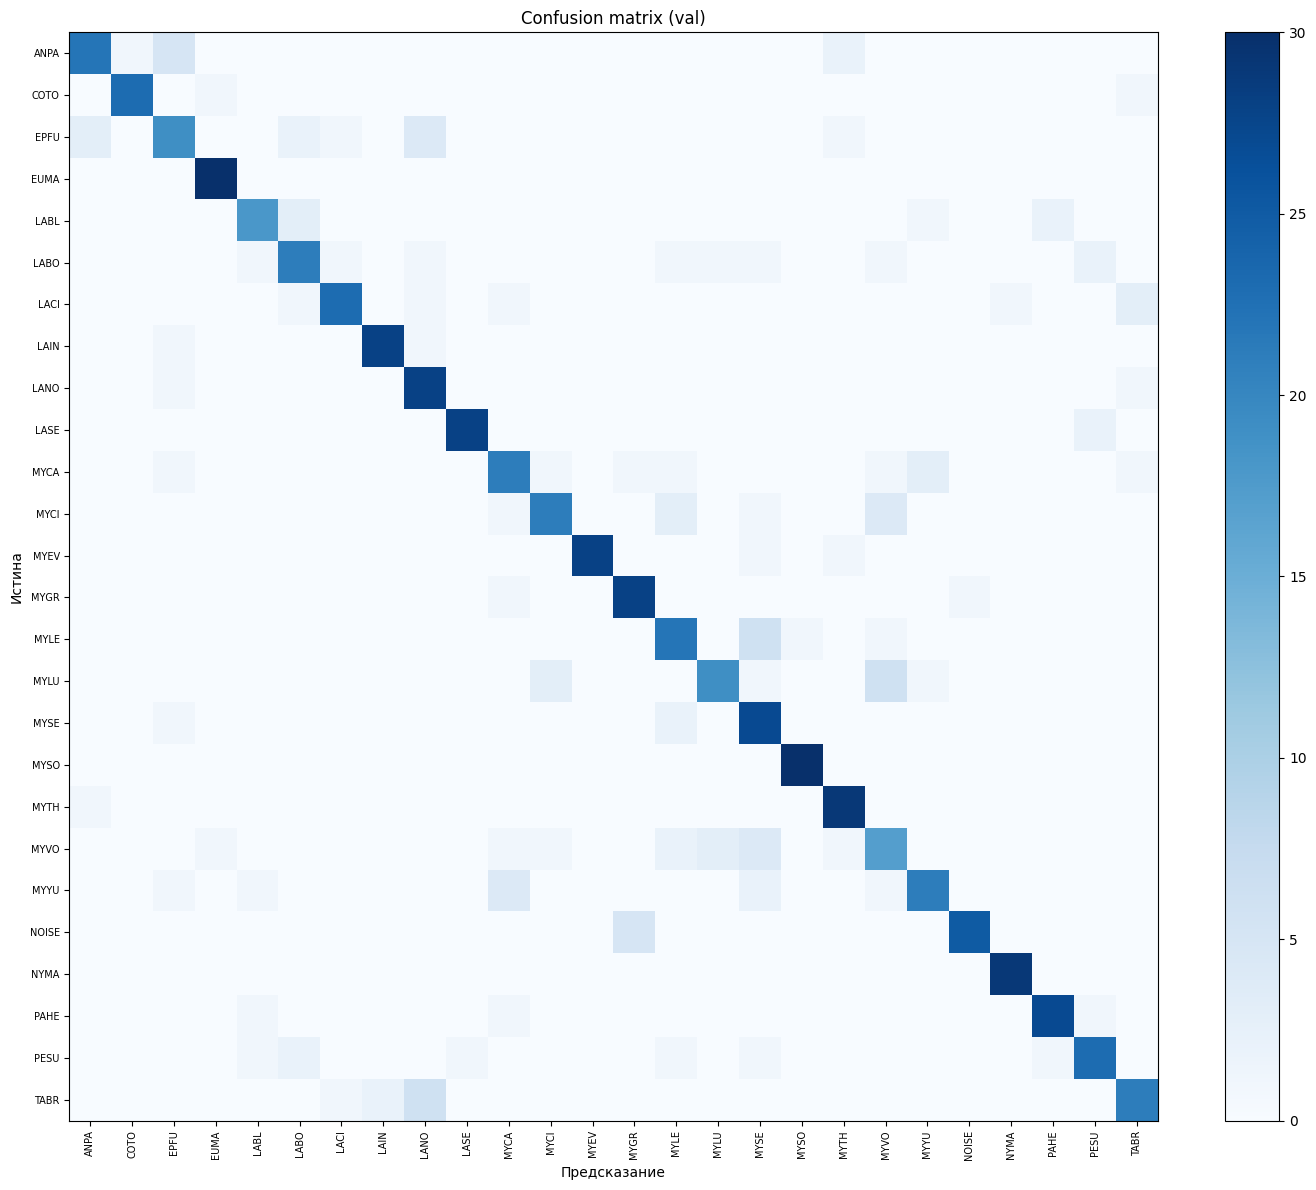

In [14]:

ckpt = torch.load(BEST_CKPT, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state"])

val_loss, metrics, y_true, y_pred = evaluate(model)
print("epoch:", ckpt.get("epoch"))
print("macro F1:", metrics["macro_f1"])
print("weighted F1:", metrics["weighted_f1"])
print("weighted precision:", metrics["weighted_prec"])
print("balanced acc:", metrics["bal_acc"])
print("accuracy:", metrics["acc"])
print()
print(classification_report(y_true, y_pred, target_names=species_sorted, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(np.arange(n_classes))
ax.set_yticks(np.arange(n_classes))
ax.set_xticklabels(species_sorted, rotation=90, fontsize=7)
ax.set_yticklabels(species_sorted, fontsize=7)
ax.set_ylabel("Истина")
ax.set_xlabel("Предсказание")
ax.set_title("Confusion matrix (val)")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()
